# 📚 PyTorch Practice Notebook - Lecture 3: Convolutional Neural Networks

**Based on:** SAIR PyTorch Mastery - Lecture 3: Convolutional Neural Networks - Vision & Beyond

**Instructions:** Complete the exercises below to test your understanding of CNNs and computer vision with PyTorch. Try to solve them without looking at the original notebook first!

**Time Estimate:** 3-4 hours

## 🆕 Enhanced Features:
- Mathematical foundation exercises
- Visualization and interpretation tasks
- Debugging CNN architectures
- Performance analysis
- Sudanese context applications

## 🔧 Setup & Imports

Run this cell first to set up your environment.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import time
import os
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import math
import matplotlib.pyplot as plt
import random


# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.6 GB


## 🆕 NEW: Debugging Exercise 0 - Find the CNN Bugs!

**Task:** This CNN class has multiple bugs. Identify and fix them all.

In [3]:
# =========== BUGGY CNN - FIND AND FIX ALL BUGS! ===========
# class BuggyCNN(nn.Module):
#     # """CNN with multiple bugs - fix them all!"""
    
#     def __init__(self, num_classes=10):
#         # BUG 1: Missing super().__init__()
        
#         # BUG 2: Inconsistent channel sizes
#         self.conv1 = nn.Conv2d(3, 32, kernel_size=5, padding=0)  # Will reduce size too much
#         self.conv2 = nn.Conv2d(32, 64, kernel_size=5, padding=0)  # Inconsistent padding
        
#         # BUG 3: Wrong calculation of flattened size
#         # For 32x32 input with kernel=5, stride=1, padding=0:
#         # conv1: 32 -> 28, conv2: 28 -> 24
#          # After maxpool (2x): 24 -> 12
#          # So flattened size should be 64 * 12 * 12 = 9216
#         self.fc1 = nn.Linear(64 * 28 * 28, 256)  # Wrong!
        
#          # BUG 4: Wrong number of classes parameter
#         self.fc2 = nn.Linear(256, 100)  # Should be num_classes
        
#          # BUG 5: Missing activation functions
#          # Should add ReLU
        
#          # BUG 6: Missing pooling layers
        
#     def forward(self, x):
#          # BUG 7: Wrong order of operations
#          x = self.conv1(x)
#          x = self.conv2(x)  # Should pool between convs
        
#          # BUG 8: Wrong reshape dimensions
#          batch_size = x.size(0)
#          x = x.view(batch_size, -1)  # This is correct but after wrong flattening calc
        
#          # BUG 9: Missing activation functions
#          x = self.fc1(x)
#          x = self.fc2(x)
        
#          # BUG 10: No output activation for classification
#          return x

# =========== YOUR FIXED VERSION ===========
class FixedCNN(nn.Module):
    """Your fixed version of the buggy CNN"""
    
    def __init__(self, num_classes=10):
        super().__init__()
        # TODO: Fix all bugs
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        #output image size 30
        #after maxpooling
        self.fc1 = nn.Linear(64 * 8 * 8, 256)

        self.fc2 = nn.Linear(256, 10)

        self.relu = nn.ReLU()

        self.softmax = nn.Softmax()
        
    def forward(self, x):
        # TODO: Fix forward pass
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool2(x)

        batch_size = x.size(0)
        x = x.view(batch_size, -1)

        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)
        x = self.softmax(x)

        return x

# Test with a sample input
#print("Testing Buggy CNN:")
test_input = torch.randn(4, 3, 32, 32)  # batch_size=4, RGB, 32x32
# buggy_model = BuggyCNN()
# try:
#     output = buggy_model(test_input)
#     print(f"Buggy output shape: {output.shape}")
# except Exception as e:
#     print(f"Buggy model error: {e}")

print("TESTING FIXED CNN")
print("="*50)

# 1. Instantiate the model
model = FixedCNN()
print("✅ Model instantiated successfully.")

# 2. Create a dummy test batch 
# (e.g., simulating 4 image frames coming from a camera feed)
batch_size = 4
test_input = torch.randn(batch_size, 3, 32, 32) 
print(f"📥 Input tensor shape: {test_input.shape}")

try:
    # 3. Run the forward pass
    output = model(test_input)
    print(f"📤 Output tensor shape: {output.shape}")
    
    # 4. Verify dimensions
    expected_shape = (batch_size, 10)
    assert output.shape == expected_shape, f"Shape mismatch! Expected {expected_shape}"
    print("✅ Output dimensions are correct.")

    # 5. Verify Softmax Math (Probabilities must sum to 1)
    # We sum across dimension 1 (the 10 classes) for each image
    probability_sums = torch.sum(output, dim=1)
    
    print("\nProbability sums for each image in the batch:")
    for i, p_sum in enumerate(probability_sums):
        # We round slightly because floating-point math can yield 0.9999999
        print(f"  Image {i+1}: {p_sum.item():.4f}")
        
    print("\n🚀 All tests passed! The network is mathematically sound.")

except Exception as e:
    print(f"\n❌ Error during forward pass: {e}")

TESTING FIXED CNN
✅ Model instantiated successfully.
📥 Input tensor shape: torch.Size([4, 3, 32, 32])
📤 Output tensor shape: torch.Size([4, 10])
✅ Output dimensions are correct.

Probability sums for each image in the batch:
  Image 1: 1.0000
  Image 2: 1.0000
  Image 3: 1.0000
  Image 4: 1.0000

🚀 All tests passed! The network is mathematically sound.


## 🎯 Exercise 1: Mathematical Foundations & Manual Implementation

### Part A: Manual 2D Convolution

**Task:** Implement 2D convolution from scratch without using PyTorch's `nn.Conv2d`.

In [5]:
# =========== YOUR CODE HERE ===========
def manual_conv2d(image, kernel, stride=1, padding=0):

    """
    Perform 2D convolution manually.
    
    Args:
        image: 2D numpy array (H, W)
        kernel: 2D numpy array (kH, kW)
        stride: Stride value
        padding: Padding value
    
    Returns:
        output: 2D numpy array
    """

    # TODO: Add padding if specified
    if padding > 0:
        padding_image = np.pad(image, pad_width=padding, mode = 'constant', constant_values=0)
    else:
       padding_image = image
    
    # TODO: Get dimensions
    h, w = padding_image.shape
    k_h, k_w = kernel.shape
    
    # TODO: Calculate output dimensions
    output_height = (h - k_h) // stride + 1
    output_width = (w  - k_w) // stride + 1
    
    # TODO: Create output array
    output = np.zeros((output_height, output_width))
    
    # TODO: Perform convolution (sliding window)
    for i in range(output_height):
     for j in range(output_width):
        row_start = i * stride
        col_start = j * stride

        region = padding_image[row_start:row_start + k_h, col_start:col_start + k_w]

        output[i, j] = np.sum(region * kernel)

    return output

# Test your implementation
print("Testing Manual Convolution:")

# Create test image
test_image = np.array([
    [1, 2, 3, 0, 1],
    [4, 5, 6, 1, 2],
    [7, 8, 9, 2, 3],
    [0, 1, 2, 3, 4],
    [1, 2, 3, 4, 5]
])

# Test with different kernels
identity_kernel = np.array([
    [0, 0, 0],
    [0, 1, 0],
    [0, 0, 0]
])

edge_kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

blur_kernel = np.ones((3, 3)) / 9

# TODO: Test your function with different kernels
# Compare with PyTorch's implementation for verification
# =====================================================

print("Result of using Identity kernal:")
manuaal_result = manual_conv2d(test_image, identity_kernel)

print(manuaal_result)
# =====================================================

print("\n compaire with PyTorch verification using Identity kernal")
image_tensor = torch.tensor(test_image).float().unsqueeze(0).unsqueeze(0) 

ikernel_tensor = torch.tensor(identity_kernel).float().unsqueeze(0).unsqueeze(0) 

conv_layer = nn.Conv2d(1, 1, kernel_size=3, stride = 1, padding=0, bias=False)

with torch.no_grad():   
    conv_layer.weight = nn.Parameter(ikernel_tensor)

itorch_result_layer = conv_layer(image_tensor)

print(itorch_result_layer.detach().numpy())
print(f"Results match: {np.allclose(manuaal_result, itorch_result_layer.detach().numpy())}")
# =====================================================

print("\n Result of using Edge kernal:")
manuaal_result = manual_conv2d(test_image, edge_kernel)

print(manuaal_result)
# =====================================================

print("\n compaire with PyTorch verification using Edge kernal")
image_tensor = torch.tensor(test_image).float().unsqueeze(0).unsqueeze(0) 

ekernel_tensor = torch.tensor(edge_kernel).float().unsqueeze(0).unsqueeze(0) 

conv_layer = nn.Conv2d(1, 1, kernel_size=3, stride = 1, padding=0, bias=False)

with torch.no_grad():   
    conv_layer.weight = nn.Parameter(ekernel_tensor)

etorch_result_layer = conv_layer(image_tensor)

print(etorch_result_layer.detach().numpy())
print(f"Results match: {np.allclose(manuaal_result, etorch_result_layer.detach().numpy())}")
# =====================================================

print("\n Result of using Blur kernal:")
manuaal_result = manual_conv2d(test_image, blur_kernel)

print(manuaal_result)
# =====================================================

print("\n compaire with PyTorch verification using Blur kernal")
image_tensor = torch.tensor(test_image).float().unsqueeze(0).unsqueeze(0) 

Bkernel_tensor = torch.tensor(blur_kernel).float().unsqueeze(0).unsqueeze(0) 

conv_layer = nn.Conv2d(1, 1, kernel_size=3, stride = 1, padding=0, bias=False)

with torch.no_grad():   
    conv_layer.weight = nn.Parameter(Bkernel_tensor)

blurtorch_result_layer = conv_layer(image_tensor)

print(blurtorch_result_layer.detach().numpy())
print(f"Results match: {np.allclose(manuaal_result, blurtorch_result_layer.detach().numpy())}")

Testing Manual Convolution:
Result of using Identity kernal:
[[5. 6. 1.]
 [8. 9. 2.]
 [1. 2. 3.]]

 compaire with PyTorch verification using Identity kernal
[[[[5. 6. 1.]
   [8. 9. 2.]
   [1. 2. 3.]]]]
Results match: True

 Result of using Edge kernal:
[[  0.  18. -18.]
 [ 30.  44. -14.]
 [-24. -16.  -8.]]

 compaire with PyTorch verification using Edge kernal
[[[[  0.  18. -18.]
   [ 30.  44. -14.]
   [-24. -16.  -8.]]]]
Results match: True

 Result of using Blur kernal:
[[5.         4.         3.        ]
 [4.66666667 4.11111111 3.55555556]
 [3.66666667 3.77777778 3.88888889]]

 compaire with PyTorch verification using Blur kernal
[[[[5.        4.        3.0000002]
   [4.666667  4.1111116 3.5555556]
   [3.666667  3.777778  3.8888888]]]]
Results match: True


### Part B: Convolution Mathematics - Shape Calculations

**Task:** Create a function that calculates output dimensions for convolutional layers.

In [6]:
# =========== YOUR CODE HERE ===========
def calculate_output_size(input_size, kernel_size, stride=1, padding=0, dilation=1):
    """
    Calculate output size for convolution.
    
    Formula: output = floor((input + 2*padding - dilation*(kernel-1) - 1) / stride) + 1
    
    Args:
        input_size: Input dimension (H or W)
        kernel_size: Kernel dimension
        stride: Stride value
        padding: Padding value
        dilation: Dilation value
    
    Returns:
        output_size: Calculated output dimension
    """
    # TODO: Implement the formula
    output = math.floor((input_size + (2 * padding) - (dilation * (kernel_size - 1)) - 1) / stride + 1)
    #pass
    return output

def calculate_cnn_output_shape(input_shape, conv_layers):
    """
    Calculate final output shape after multiple convolutional layers.
    
    Args:
        input_shape: Tuple (C, H, W)
        conv_layers: List of dicts with layer parameters
            Example: [{'type': 'conv', 'out_channels': 32, 'kernel': 3, 'stride': 1, 'padding': 1},
                      {'type': 'pool', 'kernel': 2, 'stride': 2}]

    
    Returns:
        output_shape: Tuple (C, H, W)
    """
    # TODO: Track shape through layers
    #output = ((input_shape[1] - conv_layers['kernel'] + (2 * conv_layers['padding'])) / conv_layers['stride']) + 1
    channels, height, width = input_shape

    input_shape = input_shape[1]
    for i in range(len(conv_layers)):
        layer = conv_layers[i]
        if layer['type'] == 'conv':
            height = calculate_output_size(height, layer['kernel'], layer['stride'], layer['padding'])
            width = calculate_output_size(width, layer['kernel'], layer['stride'], layer['padding'])
            channels = layer['out_channels']
        elif layer['type'] == 'pool':
            height = calculate_output_size(height, layer['kernel'], layer['stride'], 0)  # padding typically 0 for pooling
            width = calculate_output_size(width, layer['kernel'], layer['stride'], 0)
    #pass
    return (channels, height, width)

# Test cases
print("Test Cases for Shape Calculations:")
print("="*50)

# Test 1: Simple convolution
test1 = calculate_output_size(32, 3, stride=1, padding=1)
print(f"Test 1 - Input 32, kernel 3, stride 1, padding 1: {test1} (expected: 32)")

# Test 2: With pooling
test2 = calculate_output_size(32, 2, stride=2)  # MaxPool2d(2)
print(f"Test 2 - Input 32, kernel 2, stride 2 (pooling): {test2} (expected: 16)")

# Test 3: Complex CNN
layers = [
    {'type': 'conv', 'out_channels': 32, 'kernel': 3, 'stride': 1, 'padding': 1},
    {'type': 'pool', 'kernel': 2, 'stride': 2},
    {'type': 'conv', 'out_channels': 64, 'kernel': 3, 'stride': 1, 'padding': 1},
    {'type': 'pool', 'kernel': 2, 'stride': 2},
]

input_shape = (3, 32, 32)  # CIFAR-10
output_shape = calculate_cnn_output_shape(input_shape, layers)
print(f"\nComplex CNN shape calculation:")
print(f"Input shape: {input_shape}")
print(f"Output shape: {output_shape}")
print(f"Flattened size: {output_shape[0] * output_shape[1] * output_shape[2]}")
# =====================================================

Test Cases for Shape Calculations:
Test 1 - Input 32, kernel 3, stride 1, padding 1: 32 (expected: 32)
Test 2 - Input 32, kernel 2, stride 2 (pooling): 16 (expected: 16)

Complex CNN shape calculation:
Input shape: (3, 32, 32)
Output shape: (64, 8, 8)
Flattened size: 4096


### 🆕 NEW: Part C: Kernel Visualization Challenge

**Task:** Create a visualization tool that shows what different kernels do to images.

Testing Kernel Visualizer:


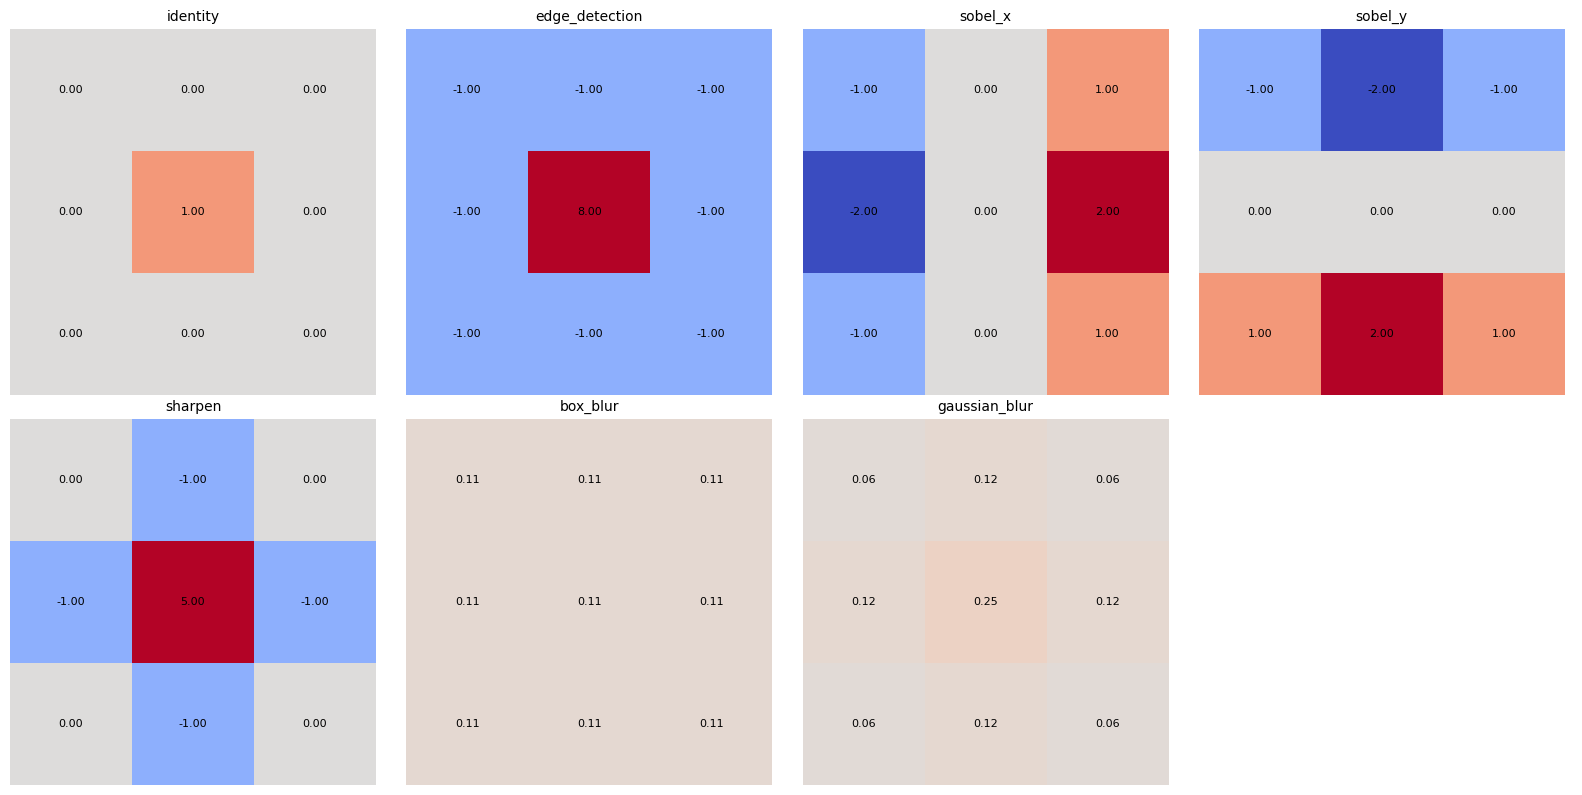

Applied edge detection to (9, 9) image -> (7, 7) output


In [7]:
class KernelVisualizer:
    """Visualize different convolution kernels"""
    
    def __init__(self):
        self.kernels = {
            'identity': np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]]),
            'edge_detection': np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]]),
            'sobel_x': np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]),
            'sobel_y': np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]]),
            'sharpen': np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]]),
            'box_blur': np.ones((3, 3)) / 9,
            'gaussian_blur': np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]]) / 16,
        }
    
    def visualize_kernels(self, image=None):
            """Visualize all kernels"""
            num_kernels = len(self.kernels)
            fig, axes = plt.subplots(2, 4, figsize=(16, 8))  # 2x4 grid for 7 kernels
            axes = axes.ravel()
            
            for idx, (name, kernel) in enumerate(self.kernels.items()):
                axes[idx].imshow(kernel, cmap='coolwarm', vmin=-2, vmax=2)
                axes[idx].set_title(f"{name}", fontsize=10)
                
                # Add kernel values as text
                for i in range(kernel.shape[0]):
                    for j in range(kernel.shape[1]):
                        axes[idx].text(j, i, f'{kernel[i, j]:.2f}', 
                                    ha='center', va='center', fontsize=8)
                
                axes[idx].axis('off')
            
            # Hide any unused subplots
            for idx in range(len(self.kernels), len(axes)):
                axes[idx].axis('off')
            
            plt.tight_layout()
            plt.show()
    
    
    def apply_to_image(self, image, kernel_name, stride=1, padding=0):
            """Apply kernel to image and show result"""
            # Get the kernel array
            kernel = self.kernels[kernel_name]
            
            # Add padding if needed
            if padding > 0:
                image = np.pad(image, padding, mode='constant')
            
            # Get dimensions
            img_h, img_w = image.shape
            kernel_h, kernel_w = kernel.shape
            
            # Calculate output dimensions
            output_h = (img_h - kernel_h) // stride + 1
            output_w = (img_w - kernel_w) // stride + 1
            
            # Create output array
            output = np.zeros((output_h, output_w))
            
            # Perform convolution
            for i in range(output_h):
                for j in range(output_w):
                    # Calculate patch boundaries correctly
                    start_i = i * stride
                    start_j = j * stride
                    end_i = start_i + kernel_h
                    end_j = start_j + kernel_w
                    
                    # Extract patch
                    patch = image[start_i:end_i, start_j:end_j]
                    
                    # Element-wise multiplication and sum
                    output[i, j] = np.sum(patch * kernel)
            
            return output

    
    def create_custom_kernel(self, weights):
        """Create and test a custom kernel"""
        # TODO: Allow user to create custom kernels
        #pass
        custom_kernel = np.array(weights)
        
        # Add to kernels dictionary
        self.kernels['custom'] = custom_kernel
        
        return custom_kernel

test_image = np.zeros((9, 9))
# Test the visualizer
print("Testing Kernel Visualizer:")
visualizer = KernelVisualizer()
visualizer.visualize_kernels(test_image)

# Test apply_to_image
result = visualizer.apply_to_image(test_image, 'edge_detection')
print(f"Applied edge detection to {test_image.shape} image -> {result.shape} output")

## 🏗️ Exercise 2: Building CNN Architectures

### Part A: Build SimpleCNN from Specifications

**Task:** Build a CNN based on these specifications:

**Requirements:**
1. Input: 32x32 RGB images (CIFAR-10)
2. Architecture:
   - Conv1: 32 filters, 3x3, padding=1 → ReLU → BatchNorm → MaxPool(2)
   - Conv2: 64 filters, 3x3, padding=1 → ReLU → BatchNorm → MaxPool(2)
   - Conv3: 128 filters, 3x3, padding=1 → ReLU → BatchNorm → MaxPool(2)
   - Flatten
   - FC1: 256 units → ReLU → Dropout(0.3)
   - FC2: 128 units → ReLU → Dropout(0.3)
   - Output: 10 units (softmax in loss)

3. Total parameters should be less than 500,000

In [8]:
# =========== YOUR CODE HERE ===========
class SimpleCNN(nn.Module):
    """Your implementation of SimpleCNN"""
    
    def __init__(self, num_classes=10):
        super().__init__()
        # TODO: Implement the architecture
        self.layer1 = nn.Conv2d(3, 32, kernel_size = 3, padding = 1)
        self.bn1 = nn.BatchNorm2d(32)

        self.layer2 = nn.Conv2d(32, 64, kernel_size = 3, padding = 1)
        self.bn2 = nn.BatchNorm2d(64)

        self.layer3 = nn.Conv2d(64, 128, kernel_size = 3, padding = 1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 128)
        self.output = nn.Linear(128, num_classes)

        self.dropout = nn.Dropout(0.5)

        self.relu = nn.ReLU()


        
    def forward(self, x):
        # TODO: Implement forward pass
        x = self.layer1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.layer2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.layer3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.output(x)
    
        return x
        
    
    def count_parameters(self):
        """Count total and trainable parameters"""
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable

# Test your model
print("Testing SimpleCNN:")
model = SimpleCNN()

# Test forward pass
test_input = torch.randn(4, 3, 32, 32)  # batch_size=4
output = model(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}")

# Count parameters
total_params, trainable_params = model.count_parameters()
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Under 500,000? {total_params < 500000}")

# Print model architecture
print("\nModel Architecture:")
print(model)
# ===========================================

Testing SimpleCNN:
Input shape: torch.Size([4, 3, 32, 32])
Output shape: torch.Size([4, 10])
Total parameters: 652,426
Trainable parameters: 652,426
Under 500,000? False

Model Architecture:
SimpleCNN(
  (layer1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (output): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p

### Part B: Build LeNet (Adapted for CIFAR-10)

**Task:** Implement AlexLeNetNet architecture adapted for 32x32 images.

In [ ]:
def __init__(self, num_classes=10):
    super().__init__()
    
    # TODO: Implement LeNet-5 architecture for CIFAR-10
    # Original LeNet-5 (for 32x32 images):
    # 1. Conv2d: 1 input channel → 6 output channels, kernel=5x5
    # 2. Tanh activation
    # 3. AvgPool2d: kernel=2x2, stride=2
    # 4. Conv2d: 6 input channels → 16 output channels, kernel=5x5
    # 5. Tanh activation
    # 6. AvgPool2d: kernel=2x2, stride=2
    # 7. Flatten
    # 8. Linear: ? features → 120 units
    # 9. Tanh activation
    # 10. Linear: 120 → 84 units
    # 11. Tanh activation
    # 12. Linear: 84 → num_classes
    
    # Hints for CIFAR-10 adaptation:
    # - CIFAR-10 has 3 input channels (RGB) not 1 (grayscale)
    # - Input size is 32x32 (same as original LeNet paper)
    # - Need to calculate the flattened size after conv/pool layers
    
    # TODO: Define the convolutional layers (features extractor)
    self.features = nn.Sequential(
        # Layer 1
        # TODO: First convolutional layer
        nn.Conv2d(3, 6, kernel_size = 5), #3x32x32 -> 6x28x28
        # TODO: Activation function (Tanh)
        nn.Tanh(),
        # TODO: Pooling layer
        nn.AvgPool2d(2, 2),  #6x28x28 -> 6x14x14


        # Layer 2
        #First convolutional layer
        nn.Conv2d(6, 16, kernel_size = 5), #6x14x14 -> 16x10x10
        #Activation function (Tanh)
        nn.Tanh(),
        # Pooling layer
        nn.AvgPool2d(2, 2) #16x10x10 -> 16x5x5
    )
    
    # TODO: Calculate the flattened size
    # After first conv (32x32 → ?x?): 
    # output_size = (input_size + 2*padding - kernel_size) / stride + 1
    # After first pool: ?x? → ?x?
    # After second conv: ?x? → ?x?
    # After second pool: ?x? → ?x?
    # flattened_size = channels * height * width
    
    #Define the fully connected layers (classifier)
    self.classifier = nn.Sequential(
        # Flatten layer
        nn.Flatten(),

        # First fully connected layer
        nn.Linear(16*5*5, 120),
        #Activation function
        nn.Tanh(),

        #Second fully connected layer
        nn.Linear(120, 84),
        #Activation function
        nn.Tanh(),

        #Output layer
        nn.Linear(84, num_classes)
    )

def forward(self, x):
    #Implement the forward pass
    # Hint: Pass through features, then classifier
    x = self.features(x)
    x = self.classifier(x)
    return x

## 🔄 Exercise 3: Complete Training & Evaluation


**Task:** Write a complete training loop for cats vs dogs with proper validation and monitoring.

In [2]:
# Load cats vs dogs dataset
# prepare the dataset and dataloader 
# defined the model 
# train and evaluate the model 
# plot the results 
# and save the model 
# test the model on new images + visualize feature maps

In [13]:
#Loading cats vs dogs dataset
import os
import zipfile

# 2. Download the Object Detection dataset
print("🚀 Downloading the Object Detection dataset...")
!kaggle datasets download -d alvarole/asirra-cats-vs-dogs-object-detection-dataset

# 3. Unzip the dataset
print("📦 Extracting files...")
dataset_dir = "asirra_detection"
if not os.path.exists(dataset_dir):
    os.makedirs(dataset_dir, exist_ok=True)
    with zipfile.ZipFile("asirra-cats-vs-dogs-object-detection-dataset.zip", 'r') as zip_ref:
        zip_ref.extractall(dataset_dir)
    
    # Clean up the zip file to save Colab disk space
    os.remove("asirra-cats-vs-dogs-object-detection-dataset.zip")

print("✅ Download and extraction complete!")
# Let's peek inside to see how the data is structured!
print("\n📁 Folders inside the dataset:")
print(os.listdir(dataset_dir))

🚀 Downloading the Object Detection dataset...
Dataset URL: https://www.kaggle.com/datasets/alvarole/asirra-cats-vs-dogs-object-detection-dataset
License(s): other
asirra-cats-vs-dogs-object-detection-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
📦 Extracting files...
✅ Download and extraction complete!

📁 Folders inside the dataset:
['Asirra: cat vs dogs']


In [14]:
#datapreprocessing to create train- test files
import shutil
print("="*50)
print("CREATING FLAT TRAIN/TEST DIRECTORIES (BULLETPROOF)")
print("="*50)

dataset_root = "asirra_detection"
base_dir = "dataset_clean"

# 1. Create ONLY train and test directories (no subdirectories)
os.makedirs(os.path.join(base_dir, 'train'), exist_ok=True)
os.makedirs(os.path.join(base_dir, 'test'), exist_ok=True)

# 2. Find all images intelligently (ignoring folder structures and XML files)
cats = []
dogs = []

print("🔍 Hunting for images...")
for root, dirs, files in os.walk(dataset_root):
    for f in files:
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            full_path = os.path.join(root, f)
            if 'cat' in f.lower():
                cats.append((f, full_path)) # Store the name AND where we found it
            elif 'dog' in f.lower():
                dogs.append((f, full_path))

print(f"Found {len(cats)} cats and {len(dogs)} dogs.")

random.shuffle(cats)
random.shuffle(dogs)

# 3. Calculate the 80% split point
cat_split = int(len(cats) * 0.8)
dog_split = int(len(dogs) * 0.8)

# 4. Group the files for training and testing
train_files = cats[:cat_split] + dogs[:dog_split]
test_files = cats[cat_split:] + dogs[dog_split:]

# 5. Copy the files directly into the train and test folders
print("🚚 Copying Training files...")
for filename, full_path in train_files:
    shutil.copy(full_path, os.path.join(base_dir, 'train', filename))

print("🚚 Copying Testing files...")
for filename, full_path in test_files:
    shutil.copy(full_path, os.path.join(base_dir, 'test', filename))

print("\n✅ Organization complete!")
print(f"Total Train Images: {len(os.listdir(os.path.join(base_dir, 'train')))}")
print(f"Total Test Images:  {len(os.listdir(os.path.join(base_dir, 'test')))}")

CREATING FLAT TRAIN/TEST DIRECTORIES (BULLETPROOF)
🔍 Hunting for images...
Found 550 cats and 550 dogs.
🚚 Copying Training files...
🚚 Copying Testing files...

✅ Organization complete!
Total Train Images: 1084
Total Test Images:  516


Loaded 3252 images for train set
Classes: {'cat': 0, 'dog': 1}
Loaded 1548 images for test set
Classes: {'cat': 0, 'dog': 1}


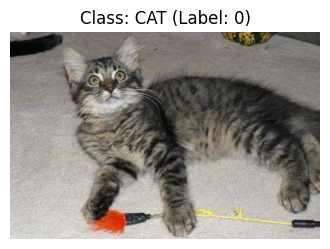

Image shape: torch.Size([3, 128, 128])
Label: 0


In [15]:
# prepare the dataset and dataloader 
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import random


class CatsDogsDataset(Dataset):
    """Dataset for Cats vs Dogs classification"""
    
    def __init__(self, root_dir, mode='train', transform=None,
                 image_extensions=('.jpg', '.jpeg', '.png')):
        super().__init__()
        self.root_dir = Path(root_dir)
        self.mode = mode
        self.transform = transform
        self.image_extensions = image_extensions
        
        self.samples = []
        # UPDATED: Our new classes
        self.class_to_idx = {'cat': 0, 'dog': 1} 
        
        # This points to 'dataset_clean/train' or 'dataset_clean/test'
        mode_dir = self.root_dir / mode 
        
        if not mode_dir.exists():
            raise ValueError(f"Directory {mode_dir} does not exist")
        
        # UPDATED: Flat directory search. We look directly in mode_dir
        for ext in self.image_extensions:
            # Grab all images in the folder
            #image_files = list(mode_dir.glob(f"*{ext}")) 
            
            all_files = list(mode_dir.iterdir())
            for image_path in all_files:
                if image_path.suffix.lower() in self.image_extensions:
                # Figure out if it's a cat or dog from the filename
                    filename = image_path.name.lower()
                    if 'cat' in filename:
                        class_name = 'cat'
                    elif 'dog' in filename:
                        class_name = 'dog'
                    else:
                        continue # Skip if it's neither
                        
                    self.samples.append({
                        'path': str(image_path),
                        'label': self.class_to_idx[class_name],
                        'class_name': class_name
                    })
        
        print(f"Loaded {len(self.samples)} images for {mode} set")
        print(f"Classes: {self.class_to_idx}")
        
        # (The transform assignment logic remains exactly the same)
        if mode == 'train' and self.transform is None:
            self.transform = self.get_default_train_transform()
        elif mode == 'test' and self.transform is None:
            self.transform = self.get_default_test_transform()

    

    def get_default_train_transform(self):
        return transforms.Compose([
            # Resize slightly larger first, then crop down to 128x128
            transforms.Resize((144, 144)), 
            transforms.RandomRotation(10),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),
            transforms.ToTensor(),
            # Standard ImageNet normalization values
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])
    
    def get_default_test_transform(self):
        return transforms.Compose([
            # Just resize and normalize for testing, no random augmentations!
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])
    

    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        try:
            # 1. Open the image and force it to be 3-color RGB
            image = Image.open(sample['path']).convert('RGB')
            
            # 2. Apply our resizing and data augmentation
            if self.transform:
                image = self.transform(image)
                
            label = sample['label']
            return image, label
            
        except Exception as e:
            # Failsafe: If an image is totally broken, print an error 
            # and return a blank black image so training doesn't crash!
            print(f"⚠️ Error loading {sample['path']}: {e}")
            
            # Create a blank black tensor in the exact shape the model expects (3 channels, 128x128)
            blank_image = torch.zeros((3, 128, 128)) 
            return blank_image, sample['label']
    
    def show_sample(self, idx):
        """A handy helper function to visually check our data"""
        sample = self.samples[idx]
        
        # Open the raw image directly from disk (before augmentations)
        image = Image.open(sample['path']).convert('RGB')
        
        plt.figure(figsize=(4, 4))
        plt.imshow(image)
        plt.title(f"Class: {sample['class_name'].upper()} (Label: {sample['label']})")
        plt.axis('off')
        plt.show()

# Create the training dataset object
train_data = CatsDogsDataset(root_dir="dataset_clean", mode='train')

# Create the testing dataset object
test_data = CatsDogsDataset(root_dir="dataset_clean", mode='test')

# Use your built-in helper to see a random cat or dog
train_data.show_sample(0)

# Or check the shape of the tensor after transforms
image, label = train_data[0]
print(f"Image shape: {image.shape}") # Should be [3, 128, 128]
print(f"Label: {label}")

In [16]:
print("="*60)
print("CREATING THE DATALOADERS")
print("="*60)

# 1. Instantiate the Custom Datasets
# This calls the __init__ function of the class we just built
train_dataset = CatsDogsDataset(root_dir='dataset_clean', mode='train')
val_dataset = CatsDogsDataset(root_dir='dataset_clean', mode='test') 

# 2. Wrap them in PyTorch DataLoaders
batch_size = 32

dataloaders = {
    # shuffle=True for training so the model doesn't memorize the order
    'train': DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
    
    # shuffle=False for validation/testing because order doesn't matter when just checking accuracy
    'val': DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
}

print(f"\nTotal Train batches per epoch: {len(dataloaders['train'])}")
print(f"Total Val batches per epoch:   {len(dataloaders['val'])}")
print("✅ DataLoaders successfully created and ready for the training loop!")

CREATING THE DATALOADERS
Loaded 3252 images for train set
Classes: {'cat': 0, 'dog': 1}
Loaded 1548 images for test set
Classes: {'cat': 0, 'dog': 1}

Total Train batches per epoch: 102
Total Val batches per epoch:   49
✅ DataLoaders successfully created and ready for the training loop!


In [17]:
#Defining th model
print("="*50)
print("PHASE 3: DEFINING THE CNN MODEL")
print("="*50)

class CatsDogsCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # ---------------------------------------------
        # 1. FEATURE EXTRACTOR (The Detective)
        # ---------------------------------------------
        self.features = nn.Sequential(
            # Block 1: Input (3, 128, 128) -> Output (16, 64, 64)
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),       # ✅ Added BatchNorm
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 2: Input (16, 64, 64) -> Output (32, 32, 32)
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),       # ✅ Added BatchNorm
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 3: Input (32, 32, 32) -> Output (64, 16, 16)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),       # ✅ Added BatchNorm
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.AdaptiveAvgPool2d((16, 16))  # ✅ INSIDE features, not overwriting it
        )
        
        # ---------------------------------------------
        # 2. CLASSIFIER (The Judge)
        # ---------------------------------------------
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16384, 512),   # 64 * 16 * 16 = 16384 ✅
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# ==========================================
# SANITY CHECK: THE DUMMY PASS
# ==========================================
model = CatsDogsCNN()

dummy_batch = torch.randn(4, 3, 128, 128)

print("Testing the math...")
output = model(dummy_batch)

print(f"Input Shape:  {dummy_batch.shape}")
print(f"Output Shape: {output.shape} (Expected: 4 images, 2 classes)")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n✅ Model initialized with {total_params:,} trainable parameters!")

PHASE 3: DEFINING THE CNN MODEL
Testing the math...
Input Shape:  torch.Size([4, 3, 128, 128])
Output Shape: torch.Size([4, 2]) (Expected: 4 images, 2 classes)

✅ Model initialized with 8,413,954 trainable parameters!


In [25]:
import torch.optim as optim
import time

print("="*60)
print("PHASE 4: TRAINING THE NETWORK")
print("="*60)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Training on device: {device}\n")

model = model.to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    start_time = time.time()

    # -----------------------------------------
    # TRAINING PHASE
    # -----------------------------------------
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in dataloaders['train']:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)   # ✅ plain tensor, no dict
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total_train
    epoch_train_acc  = correct_train / total_train

    # -----------------------------------------
    # VALIDATION PHASE
    # -----------------------------------------
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in dataloaders['val']:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)   # ✅ fixed: was model.multi_task_loss(...)

            running_val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)  # ✅ fixed: was outputs['crop_type']
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc  = correct_val / total_val

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)

    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1}/{num_epochs} | Time: {epoch_time:.0f}s")
    print(f"  Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
    print(f"  Val   Loss: {epoch_val_loss:.4f} | Val   Acc: {epoch_val_acc:.4f}\n")

print("✅ Training Complete!")

PHASE 4: TRAINING THE NETWORK
🚀 Training on device: cuda

Epoch 1/10 | Time: 19s
  Train Loss: 0.6842 | Train Acc: 0.5381
  Val   Loss: 0.6624 | Val   Acc: 0.6240

Epoch 2/10 | Time: 19s
  Train Loss: 0.6759 | Train Acc: 0.5387
  Val   Loss: 0.6566 | Val   Acc: 0.5736

Epoch 3/10 | Time: 19s
  Train Loss: 0.6651 | Train Acc: 0.5593
  Val   Loss: 0.6120 | Val   Acc: 0.6880

Epoch 4/10 | Time: 19s
  Train Loss: 0.6508 | Train Acc: 0.5907
  Val   Loss: 0.6223 | Val   Acc: 0.6647

Epoch 5/10 | Time: 18s
  Train Loss: 0.6428 | Train Acc: 0.5926
  Val   Loss: 0.6063 | Val   Acc: 0.6531

Epoch 6/10 | Time: 19s
  Train Loss: 0.6366 | Train Acc: 0.5919
  Val   Loss: 0.5947 | Val   Acc: 0.6880

Epoch 7/10 | Time: 19s
  Train Loss: 0.6374 | Train Acc: 0.6061
  Val   Loss: 0.5619 | Val   Acc: 0.7306

Epoch 8/10 | Time: 19s
  Train Loss: 0.6255 | Train Acc: 0.6067
  Val   Loss: 0.5638 | Val   Acc: 0.7209

Epoch 9/10 | Time: 18s
  Train Loss: 0.6150 | Train Acc: 0.6061
  Val   Loss: 0.5673 | Val   A

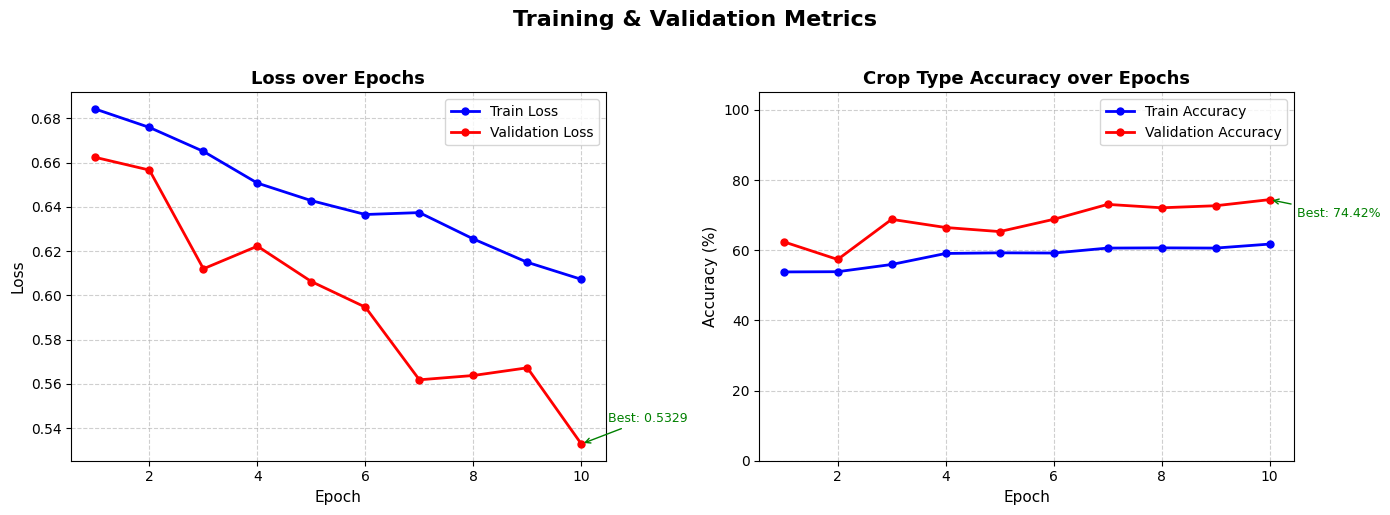

📊 Plot saved as 'training_metrics.png'


In [27]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training_metrics(train_losses, val_losses, train_accs, val_accs):
    if not train_losses:
        print("⚠️  No training data to plot (num_epochs = 0)")
        return

    epochs = range(1, len(train_losses) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Training & Validation Metrics', fontsize=16, fontweight='bold', y=1.02)

    # ── Plot 1: Loss ──────────────────────────────────────────
    ax1 = axes[0]
    ax1.plot(epochs, train_losses, 'b-o', label='Train Loss',      linewidth=2, markersize=5)
    ax1.plot(epochs, val_losses,   'r-o', label='Validation Loss', linewidth=2, markersize=5)
    ax1.set_title('Loss over Epochs', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=11)
    ax1.set_ylabel('Loss', fontsize=11)
    ax1.legend(fontsize=10)
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Annotate best validation loss
    best_val_loss_epoch = int(np.argmin(val_losses)) + 1
    best_val_loss_value = min(val_losses)
    ax1.annotate(
        f'Best: {best_val_loss_value:.4f}',
        xy=(best_val_loss_epoch, best_val_loss_value),
        xytext=(best_val_loss_epoch + 0.5, best_val_loss_value + 0.01),
        arrowprops=dict(arrowstyle='->', color='green'),
        fontsize=9, color='green'
    )

    # ── Plot 2: Accuracy ──────────────────────────────────────
    ax2 = axes[1]
    ax2.plot(epochs, [a * 100 for a in train_accs], 'b-o', label='Train Accuracy',      linewidth=2, markersize=5)
    ax2.plot(epochs, [a * 100 for a in val_accs],   'r-o', label='Validation Accuracy', linewidth=2, markersize=5)
    ax2.set_title('Crop Type Accuracy over Epochs', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=11)
    ax2.set_ylabel('Accuracy (%)', fontsize=11)
    ax2.set_ylim(0, 105)
    ax2.legend(fontsize=10)
    ax2.grid(True, linestyle='--', alpha=0.6)

    # Annotate best validation accuracy
    best_val_acc_epoch = int(np.argmax(val_accs)) + 1
    best_val_acc_value = max(val_accs) * 100
    ax2.annotate(
        f'Best: {best_val_acc_value:.2f}%',
        xy=(best_val_acc_epoch, best_val_acc_value),
        xytext=(best_val_acc_epoch + 0.5, best_val_acc_value - 5),
        arrowprops=dict(arrowstyle='->', color='green'),
        fontsize=9, color='green'
    )

    plt.tight_layout()
    plt.savefig('training_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("📊 Plot saved as 'training_metrics.png'")


# ── Call it right after your training loop ────────────────────
plot_training_metrics(train_losses, val_losses, train_accs, val_accs)

In [28]:
# -----------------------------------
# SAVE THE MODEL
# -----------------------------------
model_path = "cats_dogs_cnn.pth"

torch.save(model.state_dict(), model_path)

print(f"✅ Model saved successfully at: {model_path}")

✅ Model saved successfully at: cats_dogs_cnn.pth


In [29]:
# -----------------------------------
# Test the model on new images
# -----------------------------------

#load model
model = CatsDogsCNN()
model.load_state_dict(torch.load("cats_dogs_cnn.pth", map_location=device))
model.to(device)
model.eval()

CatsDogsCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(16, 16))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_featu

In [30]:
# -----------------------------------
# Define a prediction function
# -----------------------------------

import matplotlib.pyplot as plt
from PIL import Image

# Same transform as test!
test_transform = CatsDogsDataset(
                root_dir='dataset_clean', 
                mode='test'
            ).get_default_test_transform()

def predict_image(image_path):
    # Load image
    image = Image.open(image_path).convert('RGB')
    
    # Transform
    input_tensor = test_transform(image).unsqueeze(0)  # add batch dim
    input_tensor = input_tensor.to(device)
    
    # Predict
    with torch.no_grad():
        outputs = model(input_tensor)
        _, predicted = torch.max(outputs, 1)
    
    class_names = ['cat', 'dog']
    predicted_class = class_names[predicted.item()]
    
    # Show result
    plt.imshow(image)
    plt.title(f"Prediction: {predicted_class.upper()}")
    plt.axis('off')
    plt.show()
    
    return predicted_class

Loaded 1548 images for test set
Classes: {'cat': 0, 'dog': 1}


In [31]:
import requests
from PIL import Image
from io import BytesIO

url = "https://images.pexels.com/photos/30002394/pexels-photo-30002394.jpeg"

img = Image.open(BytesIO(requests.get(url).content))
img.show()

predict_image(img)


AttributeError: read

## 🧪 Challenge Problems

### Challenge 1: Optimize CNN for Mobile Deployment

**Task:** Create a lightweight CNN for mobile deployment in Sudanese farms.

In [ ]:
# class MobileSudaneseCNN(nn.Module):
#     """Lightweight CNN for mobile deployment"""
    
#     def __init__(self, num_classes=5):
#         super().__init__()
        
#         # TODO: Design a CNN with:
#         # 1. Less than 100,000 parameters
#         # 2. Fast inference on mobile CPU
#         # 3. Good accuracy for crop classification
        
#         # Techniques to consider:
#         # - Depthwise separable convolutions
#         # - Bottleneck layers
#         # - Reduced channel counts
#         # - Efficient activation functions
        
#     def forward(self, x):
#         pass
    
#     def benchmark(self, input_size=(1, 3, 224, 224)):
#         """Benchmark model performance"""
#         # TODO: Measure parameters, FLOPs, inference time
#         pass

# print("Testing Mobile CNN:")
# mobile_cnn = MobileSudaneseCNN()
# mobile_cnn.benchmark()

In [12]:
import torch
import torch.nn as nn
import time
from typing import Tuple

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3, 
                                   stride=stride, padding=1, groups=in_channels, bias=False)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU6(inplace=True) # Mobile-friendly ReLU

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        return self.relu(x)

class MobileSudaneseCNN(nn.Module):
    """Lightweight CNN for mobile deployment (Under 100k params)"""
    
    def __init__(self, num_classes=5):
        super().__init__()
        
        # Initial Conv: Fast reduction of spatial dimensions
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU6(inplace=True)
        )

        # Depthwise Separable Layers
        self.layers = nn.Sequential(
            DepthwiseSeparableConv(16, 32, stride=2),   # 56x56
            DepthwiseSeparableConv(32, 64, stride=2),   # 28x28
            DepthwiseSeparableConv(64, 64, stride=1),   # 28x28
            DepthwiseSeparableConv(64, 128, stride=2),  # 14x14
            DepthwiseSeparableConv(128, 128, stride=2), # 7x7
        )

        # Global Classifier
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        x = self.stem(x)
        x = self.layers(x)
        x = self.classifier(x)
        return x
    
    def benchmark(self, input_size=(1, 3, 224, 224)):
        """Benchmark model performance: Params and Inference Time"""
        total_params = sum(p.numel() for p in self.parameters())
        print(f"--- Model Benchmark ---")
        print(f"Total Parameters: {total_params:,}")
        
        dummy_input = torch.randn(input_size)
        
        # Warm-up
        for _ in range(10):
            _ = self(dummy_input)
            
        # Inference Timing
        start_time = time.time()
        for _ in range(100):
            _ = self(dummy_input)
        avg_time = (time.time() - start_time) / 100
        
        print(f"Average Inference Time (CPU): {avg_time*1000:.2f} ms")
        print(f"Target < 100k Params: {'PASSED' if total_params < 100000 else 'FAILED'}")

print("Testing Mobile CNN:")
mobile_cnn = MobileSudaneseCNN()
mobile_cnn.benchmark()

Testing Mobile CNN:
--- Model Benchmark ---
Total Parameters: 35,909
Average Inference Time (CPU): 5.53 ms
Target < 100k Params: PASSED


### Challenge 2: Multi-Task CNN

**Task:** Create a CNN that performs multiple tasks for Sudanese agriculture.

In [ ]:
# class MultiTaskAgricultureCNN(nn.Module):
#     """CNN for multiple agricultural tasks"""
    
#     def __init__(self):
#         super().__init__()
        
#         # Shared backbone
#         self.backbone = nn.Sequential(
#             # TODO: Shared convolutional layers
#         )
        
#         # Task-specific heads
#         self.crop_classifier = nn.Sequential(
#             # TODO: Classify crop type (5 classes)
#         )
        
#         self.health_classifier = nn.Sequential(
#             # TODO: Classify health status (3 classes)
#         )
        
#         self.yield_regressor = nn.Sequential(
#             # TODO: Predict yield (continuous value)
#         )
        
#     def forward(self, x):
#         features = self.backbone(x)
        
#         crop_pred = self.crop_classifier(features)
#         health_pred = self.health_classifier(features)
#         yield_pred = self.yield_regressor(features)
        
#         return {
#             'crop_type': crop_pred,
#             'health_status': health_pred,
#             'yield': yield_pred
#         }
    
#     def multi_task_loss(self, predictions, targets):
#         """Compute combined loss for all tasks"""
#         # TODO: Weighted combination of:
#         # 1. Cross-entropy for crop classification
#         # 2. Cross-entropy for health classification
#         # 3. MSE for yield regression
#         pass

# print("Testing Multi-Task CNN:")
# # TODO: Implement and test

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiTaskAgricultureCNN(nn.Module):
    """CNN for multiple agricultural tasks"""
    
    def __init__(self, img_size=64):
        super().__init__()
        
        # --- Shared backbone ---
        # 3 conv blocks: each doubles channels and halves spatial dims via MaxPool
        # Input: (B, 3, H, W) → Output: (B, 128, H/8, W/8)
        self.backbone = nn.Sequential(
            # Block 1: 3 → 32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # (B, 32, H, W)
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                               # (B, 32, H/2, W/2)

            # Block 2: 32 → 64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # (B, 64, H/2, W/2)
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                               # (B, 64, H/4, W/4)

            # Block 3: 64 → 128
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # (B, 128, H/4, W/4)
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                               # (B, 128, H/8, W/8)

            nn.AdaptiveAvgPool2d((4, 4)),                  # (B, 128, 4, 4) — fixed regardless of input size
            nn.Flatten(),                                  # (B, 2048)
        )
        
        backbone_out = 128 * 4 * 4  # 2048

        # --- Task-specific heads ---

        # Crop type: 5 classes (e.g. wheat, corn, rice, soy, cotton)
        self.crop_classifier = nn.Sequential(
            nn.Linear(backbone_out, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, 5),          # logits for 5 crop classes
        )

        # Health status: 3 classes (healthy, stressed, diseased)
        self.health_classifier = nn.Sequential(
            nn.Linear(backbone_out, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, 3),          # logits for 3 health classes
        )

        # Yield: single continuous value (e.g. tonnes/hectare)
        self.yield_regressor = nn.Sequential(
            nn.Linear(backbone_out, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 1),           # scalar yield prediction
        )

    def forward(self, x):
        features = self.backbone(x)

        crop_pred   = self.crop_classifier(features)       # (B, 5)
        health_pred = self.health_classifier(features)     # (B, 3)
        yield_pred  = self.yield_regressor(features)       # (B, 1)

        return {
            'crop_type':     crop_pred,
            'health_status': health_pred,
            'yield':         yield_pred,
        }

    def multi_task_loss(self, predictions, targets, weights=None):
        """
        Compute weighted multi-task loss.

        Args:
            predictions : dict returned by forward()
            targets     : dict with keys
                            'crop_type'     – (B,) int64 class indices
                            'health_status' – (B,) int64 class indices
                            'yield'         – (B,) or (B,1) float32
            weights     : optional dict {'crop': float, 'health': float, 'yield': float}
                          defaults to equal weighting (1, 1, 1)

        Returns:
            total_loss  : scalar tensor (backpropagatable)
            loss_dict   : individual losses for logging
        """
        if weights is None:
            weights = {'crop': 1.0, 'health': 1.0, 'yield': 1.0}

        # 1. Crop classification — cross-entropy
        crop_loss = F.cross_entropy(
            predictions['crop_type'],
            targets['crop_type']
        )

        # 2. Health classification — cross-entropy
        health_loss = F.cross_entropy(
            predictions['health_status'],
            targets['health_status']
        )

        # 3. Yield regression — MSE
        yield_pred = predictions['yield'].squeeze(1)        # (B,)
        yield_true = targets['yield'].float()
        yield_loss = F.mse_loss(yield_pred, yield_true)

        # 4. Weighted sum
        total_loss = (
            weights['crop']   * crop_loss   +
            weights['health'] * health_loss +
            weights['yield']  * yield_loss
        )

        loss_dict = {
            'crop_loss':   crop_loss.item(),
            'health_loss': health_loss.item(),
            'yield_loss':  yield_loss.item(),
            'total_loss':  total_loss.item(),
        }
        return total_loss, loss_dict


# ── Quick smoke test ──────────────────────────────────────────────────────────
print("Testing Multi-Task CNN:")

torch.manual_seed(42)
BATCH = 4

model = MultiTaskAgricultureCNN(img_size=64)
model.eval()

# Dummy RGB images
x = torch.randn(BATCH, 3, 64, 64)

# Forward pass
with torch.no_grad():
    preds = model(x)

print(f"  crop_type     shape : {preds['crop_type'].shape}")      # (4, 5)
print(f"  health_status shape : {preds['health_status'].shape}")  # (4, 3)
print(f"  yield         shape : {preds['yield'].shape}")          # (4, 1)

# Dummy targets
targets = {
    'crop_type':     torch.randint(0, 5, (BATCH,)),
    'health_status': torch.randint(0, 3, (BATCH,)),
    'yield':         torch.rand(BATCH) * 10,              # 0–10 t/ha
}

# Loss (needs grad)
model.train()
preds_train = model(x)
loss, loss_dict = model.multi_task_loss(
    preds_train, targets,
    weights={'crop': 1.0, 'health': 1.0, 'yield': 0.01}  # scale yield loss
)

print(f"\n  crop_loss   : {loss_dict['crop_loss']:.4f}")
print(f"  health_loss : {loss_dict['health_loss']:.4f}")
print(f"  yield_loss  : {loss_dict['yield_loss']:.4f}")
print(f"  total_loss  : {loss_dict['total_loss']:.4f}")

total_params = sum(p.numel() for p in model.parameters())
print(f"\n  Total parameters: {total_params:,}")
print("\nAll checks passed ✓")

Testing Multi-Task CNN:
  crop_type     shape : torch.Size([4, 5])
  health_status shape : torch.Size([4, 3])
  yield         shape : torch.Size([4, 1])

  crop_loss   : 1.6090
  health_loss : 1.3436
  yield_loss  : 27.1812
  total_loss  : 3.2244

  Total parameters: 1,880,105

All checks passed ✓


## 📊 Assessment Questions

Answer these questions in markdown cells:

### Q1: What's the key difference between a dense layer and a convolutional layer? When would you use each?

The difference in the parameters used and what the layer learn, dense layer use many parameter of different parameters values for each input batch while convolution layer use shared parameters to all input data for each output channel. Also the denselayer learn general patterens while convolution layer learn specific features, starting with simple features then deeper layers learn more complex features.

### Q2: How does padding affect convolution output size and feature learning?

Padding increase the size of the output as we add more pixels at the edges of the image snd this result in more multiplications by the filter at the edges of the image. This helps preserve spatial dimensions and ensures that edge pixels are included more effectively in the convolution process. As a result, padding improves features learning specially at the edges of an image by enabling the kernel to capture information that would otherwise be lost, leading to richer and more informative feature maps.

### Q3: Why do CNNs use small kernel sizes (3x3) instead of large ones?

CNNs use small kernels, like 3×3, because they efficiently capture local patterns in the input while keeping the number of parameters low. Stacking multiple small kernel layers allows the network to learn complex features hierarchically, preserving important details including edges without losing spatial information. Large kernels, in contrast, can miss fine grained features and increase computational cost.

### Q4: What's the purpose of pooling layers in CNNs? What are the trade-offs between max pooling and average pooling?

Pooling layer is used to reduce the dimentionaliy of the output of the convolution layer. As max pooling takes the maximum pixel value between the position pixels it allow to detect if something exist. Average pooling on the other hand take the average of all pixels it allow to detect the common pattern in the reegion of pixels or the intensity.

### Q5: How does BatchNorm help with CNN training? Why does it behave differently during training vs inference?

Batch Normalization improves training stability by normalizing the activations of each layer, reducing the impact of changing parameter values on the distribution of these activations. This helps the network learn faster and more reliably.

During training, BatchNorm computes the mean and variance from each mini-batch, so the normalization changes slightly at every iteration. In contrast, during inference, it uses fixed running estimates of the mean and variance collected during training, making the behavior consistent and deterministic.

### Q6: Explain the concept of "receptive field" in CNNs. How does it change through the network?

The receptive field of a neuron in a CNN is the region of the input image that influences that neuron’s output. In other words, it represents how much of the original image a neuron “sees.”

In convolutional networks, the receptive field increases as we go deeper into the network. Early layers have small receptive fields, allowing them to capture simple local features such as edges and corners. As layers are stacked, the receptive field grows, enabling middle layers to detect patterns and textures. In deeper layers, the receptive field becomes large enough to capture high-level structures and entire objects.

This progressive increase allows CNNs to learn features hierarchically, from simple to complex representations. 

### Q7: What's the difference between Conv1D, Conv2D, and Conv3D? Give real-world examples for each.

Each one is used for differnt data types as follows:

1. Conv1D is used for sequential data (time series, text, audio). For example it is applied in:

   1.1. Text classification (sentiment analysis) like in Twitter/X, Amazon reviews and google search. 

   1.2. Audio process (speech recognition) like in google assistant /Siri / Alexa.

2. Conv2D for image. For example it is used in:
   2.1. Image classification (ResNet Style) like in Google/Apple photos.

   2.2. Object detection like Tesla Autopilot it is used to detect cars, pedestrians, traffic lights.

   2.3. Medical imaging (MRI Analysis) like in IBM Watson Health for Cancer detection.

3. Cinv3D for volumetric or video data. For example it is used in:

   3.1. Videos classification (Action Recognition) to detect violence content.
   
   3.2. 3D medical scans (CT, MRI volumes).

### 🆕 Q8: Design a CNN architecture for classifying Sudanese traditional clothing. What considerations would you make?

Taking the scenario of classifiying whether the clothes in the image is "Tube" or "Jalabia". 

Input: Image (e.g., 224 × 224 × 3)
Convolution Block 1
Conv2d (3×3, 32 filters) + ReLU
BatchNorm2d(2, 2)
MaxPooling2d(2×2)

Convolution Block 2
Conv2d (3×3, 64 filters) + ReLU
BatchNorm2d(2, 2)
MaxPooling2d(2×2)

Convolution Block 3
Conv2d (3×3, 128 filters) + ReLU
BatchNorm2d(2, 2)
MaxPooling2d(2×2)

Fully Connected Layers
Flatten
Dense (128) + ReLU
Dropout (0.5)
Output Layer (2 neurons, Softmax)

Key Considerations

1. Clothing Variability

2. Data Collection Challenges

3. Class Imbalance

4. Input Resolution"Low resolution = lost detail"

### 🆕 Q9: How would you optimize a CNN for deployment on mobile phones in rural Sudan?

   1. Architecture-Level Optimization
         Instead of standard convolutions, use structural efficiencies that reduce the "compute budget."

         Depthwise Separable Convolutions: As implemented in the MobileSudaneseCNN, this reduces operations (FLOPs) by approximately 8x to 9x compared to standard layers.

         Global Average Pooling (GAP): Avoid large Fully Connected (FC) layers at the end of the network. FC layers often account for 90% of the total model size (in MBs), which is a nightmare for users with limited storage.

         Inverted Residuals: Use MobileNetV3 or ShuffleNetV2 patterns to maintain high accuracy while keeping the feature maps slim.

   2. Model Quantization (The Most Impactful Step)
         Standard models use 32-bit floating-point numbers (FP32). Mobile CPUs in mid-range or older phones perform much better with integers.
            * Post-Training Quantization (PTQ): Convert weights from $FP32$ to INT8. This reduces the model size by 4x (e.g., a 40MB model becomes 10MB) with negligible accuracy loss.
            * Weight Pruning: Remove "dead" neurons or connections that don't contribute to the prediction. This makes the model sparser and easier to compress for over-the-air updates.



### 🆕 Q10: Create a debugging checklist for when your CNN isn't learning (low accuracy).


The check list:
1. Data Issues

   1.1 Check labels:

      - Are labels correct? (no mix-ups like cat labeled as dog)
      - Are classes balanced?
      - Any missing or corrupted labels?

   1.2 For Visualize samples
   Plot a few training images with labels
   Confirm:
   Images are loaded correctly
   Labels match the image content

   1.3 Normalization
   Are inputs normalized properly? (e.g., mean/std scaling)
   Wrong normalization → model struggles to learn

   1.4 Data leakage
   Ensure:
   No overlap between train & validation sets
   No duplicated samples across splits

2. Model Architecture Checks:

   2.1 Output layer: Does it Matches number of classes?
   2.2 Activation functions.
   2.3 Model size
   Too small → underfitting
   Too large → overfitting (but still should learn training set)

3. Loss Function & Targets

   3.1 Correct loss function?
   Binary classification → BCELoss / BCEWithLogitsLoss
   Multi-class → CrossEntropyLoss
   3.2 The target format

4. Training Loop Bugs
   4.1 Check gradient flow
   4.2 Model mode
   4.3 Loss decreasing?
   If loss is flat → something is wrong
   If loss is NaN → numerical instability

5. Learning Rate Problems: avoid too high(Loss jumps or becomes NaN) or too.

6. low(Model learns VERY slowly or not at all).
   Weight Initialization
   Bad initialization → no learning.

7. Regularization & Augmentation
   Usually PyTorch defaults are fine
   But if custom layers → double check


**You're ready for Lecture 4: Transfer Learning & Advanced Architectures!** 🎉

## 💡 Tips for Success

1. **Start Simple**: Begin with manual convolution, then use PyTorch layers
2. **Visualize Everything**: Use the visualization tools to understand what's happening
3. **Test Shapes**: Always print tensor shapes between layers
4. **Consider Sudanese Context**: Think about real applications in Sudan
5. **Benchmark**: Compare different architectures and techniques
6. **🆕 Debug Systematically**: When something doesn't work, check shapes, devices, gradients
7. **🆕 Think About Deployment**: Consider computational constraints

## 🤝 Need Help?

- Review Lecture 3 notebook for concepts
- Use PyTorch documentation for specific APIs
- Test with small examples first
- Visualize intermediate results
- 🆕 Create minimal reproducible examples when debugging
- 🆕 Benchmark different approaches to find optimal solutions

### Very Important Note:
# Go to Chapter 11 of Hands On Machine Learning with sklearn and PyTorch by Aurélien Géron.and solve the exercises at the end of the chapter.and add it in this notebook as well.

### 1. What is the problem that Glorot initialization and He initialization aim to fix?

    Glorot (Xavier) and He initialization are designed to fix the vanishing and exploding gradient problem in deep neural networks.

    These issues happen when gradients become too small (learning stops) or too large (training becomes unstable) during backpropagation.

    They solve this by carefully choosing initial weights so that:

        - The variance of activations stays consistent across layers
        - The gradients remain stable when flowing backward

    This helps the network train efficiently without signals shrinking or blowing up.

        - Glorot initialization → best for sigmoid/tanh
        - He initialization → best for ReLU and its variants

2. Is it OK to initialize all the weights to the same value as long as that value is selected randomly using He initialization?

    No, it’s not okay to initialize all weights to the same value—even if that value follows He initialization.

        Doing this causes symmetry: all neurons become identical.
        They learn the same features and update in the same way.
        The network effectively behaves like it has only one neuron per layer.

    He initialization is meant to randomly sample weights with the right variance, not assign a single value.

3. Is it OK to initialize the bias terms to 0?

    Yes, it is perfectly fine to initialize bias terms to 0.

        - Biases don’t need random values because symmetry is already broken by random weights
        - Initializing them to zero is simple and works well in practice
        - This is a common standard in deep learning (including with He initialization)

    Key idea: Only weights need randomness; biases can safely start at zero.

### 4. In which cases would you want to use each of the activation functions we discussed in this chapter?

General Rule:

    ReLU → default starting point.

    Swish / GELU → better for deep, complex models.

    Choose based on speed vs performance trade-off.

Common Activation Functions:

    ✅ ReLU (Rectified Linear Unit):

        Use for most tasks (default).

        Fast and efficient.

        Works well in CNNs and standard networks.

    ✅ Leaky ReLU:

        Use when facing dying ReLU problem.

        Keeps small gradient for negative values.

        Good for stable and fast training.

    ✅ PReLU:

        Use when you want the model to learn the activation

        Works well on large datasets

        ⚠️ Risk of overfitting on small data

    ✅ ELU

        Use when you want faster convergence

        Produces outputs closer to zero mean

        Slightly slower than ReLU

    ✅ SELU

        Use for self-normalizing networks (MLPs only)

        Requires:

            Standardized inputs

            Specific initialization (LeCun)

            No dropout / skip connections

Advanced / Modern Choices

    ✅ GELU

        Use for high-performance deep models
        
        Common in Transformers

        Handles complex patterns well

    ✅ Swish (SiLU)

        Often better than ReLU

        Smooth → improves optimization

        Great for deep networks

    ✅ SwiGLU

        Used in Transformer architectures

        Adds gating mechanism → more expressive

    ✅ Mish

        Similar to Swish/GELU

        Slight performance boost, but more compute

Special Cases

    ✅ RReLU

        Use as a regularizer

        Helps reduce overfitting

    ✅ ReLU² (ReLU squared)

        Useful for sparse models

    ✅ Hard variants (Hardsigmoid, Hardswish)

        Use for mobile / low-latency systems

        Faster approximations of complex activations

Final Takeaway

    Simple model? → ReLU

    Deep/complex model? → Swish or GELU

    Speed critical (mobile)? → ReLU / Hardswish

    Special architecture? → SELU or SwiGLU

### 5. What may happen if you set the momentum hyperparameter too close to 1 (e.g., 0.99999) when using an SGD optimizer?

    Setting momentum too close to 1 (e.g., 0.99999) makes SGD behave like it has almost no friction.

    Very large updates → momentum builds up excessively

    Overshooting → skips past the minimum repeatedly

    Oscillations → keeps bouncing around the minimum

    Slow convergence or divergence → may fail to stabilize

    Key idea: Too much momentum = unstable training.

    Typical safe value: ~0.9

### 6. Name three ways you can produce a sparse model.

    Three common ways to produce a sparse model (many weights = 0):

        1. L1 Regularization (Lasso / Elastic Net):

            Adds a penalty that pushes unimportant weights to zero

        2. Weight Pruning:

            Train normally, then remove small weights by setting them to zero.

        3. Sparsity-Inducing Regularization:

            Apply strong L1 penalty during training to encourage zero weights.

    Key idea: All methods aim to eliminate unnecessary connections to make the model simpler and more efficient.

### 7. Does dropout slow down training? Does it slow down inference (i.e., making predictions on new instances)? What about MC dropout?

    Dropout during training → Yes, slows down training

        * Model learns more robust features → needs more epochs

    Dropout during inference → No, does not slow down

        * Dropout is turned off, so prediction is normal

    MC Dropout during inference → Yes, slows down a lot

        * Requires multiple forward passes and averaging

    Key idea:

        Dropout slows training only
        MC Dropout slows inference due to repeated predictions

### 8. Practice training a deep neural network on the CIFAR10 image dataset:

a. Load CIFAR10 just like you loaded the FashionMNIST dataset in Chapter 10, but using torchvision.datasets.CIFAR10 instead of FashionMNIST. The dataset is composed of 60,000 32 × 32–pixel color images (50,000 for training, 10,000 for testing) with 10 classes.


In [ ]:
import torch
import torchvision
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader, random_split

# Define the transform: convert to Image (Tensor subclass) and scale to [0, 1]
toTensor = T.Compose([
    T.ToImage(), 
    T.ToDtype(torch.float32, scale=True)
])

# Load the 50,000 training images
train_and_valid_data = torchvision.datasets.CIFAR10(
    root="datasets", train=True, download=True, transform=toTensor)

# Load the 10,000 test images
test_data = torchvision.datasets.CIFAR10(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42) # For reproducibility
train_data, valid_data = random_split(train_and_valid_data, [45_000, 5_000])

# Create DataLoaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

100%|██████████| 170M/170M [00:02<00:00, 77.7MB/s] 


### b. Build a DNN with 20 hidden layers of 100 neurons each (that’s too many, but it’s the point of this exercise). Use He initialization and the Swish activation function (using nn.SiLU). Since this is a classification task, you will need an output layer with one neuron per class.

In [2]:
import torch
import torch.nn as nn

torch.manual_seed(42)

n_inputs = 32*32*3
n_hidden_layers = 20
n_neurons = 100
n_outputs = 10

layers = [nn.Flatten()]

# Hidden layers
for i in range(n_hidden_layers):
    in_features = n_inputs if i==0 else n_neurons
    layers.append(nn.Linear(in_features, n_neurons))
    layers.append(nn.BatchNorm1d(n_neurons))  # optional but recommended
    layers.append(nn.SiLU())

# Output layer
layers.append(nn.Linear(n_neurons, n_outputs))

model = nn.Sequential(*layers)

# He init
def initialize_weights(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
        nn.init.zeros_(module.bias)

model.apply(initialize_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3072, out_features=100, bias=True)
  (2): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): SiLU()
  (4): Linear(in_features=100, out_features=100, bias=True)
  (5): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): SiLU()
  (7): Linear(in_features=100, out_features=100, bias=True)
  (8): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (9): SiLU()
  (10): Linear(in_features=100, out_features=100, bias=True)
  (11): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (12): SiLU()
  (13): Linear(in_features=100, out_features=100, bias=True)
  (14): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (15): SiLU()
  (16): Linear(in_features=100, out_features=100, bias=True)
  (17): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_r

### c. Using NAdam optimization and early stopping, train the network on the CIFAR10 dataset. Remember to search for the right learning rate each time you change the model’s architecture or hyperparameters.


Epoch 01 | Train Loss: 1.8441 | Val Loss: 1.7347 | Val Acc: 0.3810
Epoch 02 | Train Loss: 1.6056 | Val Loss: 1.6159 | Val Acc: 0.4254
Epoch 03 | Train Loss: 1.5013 | Val Loss: 1.5463 | Val Acc: 0.4606
Epoch 04 | Train Loss: 1.4267 | Val Loss: 1.5111 | Val Acc: 0.4730
Epoch 05 | Train Loss: 1.3640 | Val Loss: 1.5155 | Val Acc: 0.4802
Epoch 06 | Train Loss: 1.3089 | Val Loss: 1.4927 | Val Acc: 0.4800
Epoch 07 | Train Loss: 1.2620 | Val Loss: 1.4757 | Val Acc: 0.4848
Epoch 08 | Train Loss: 1.2168 | Val Loss: 1.5108 | Val Acc: 0.4932
Epoch 09 | Train Loss: 1.1737 | Val Loss: 1.4946 | Val Acc: 0.4872
Epoch 10 | Train Loss: 1.1353 | Val Loss: 1.5633 | Val Acc: 0.4784
Epoch 11 | Train Loss: 1.0976 | Val Loss: 1.5194 | Val Acc: 0.4874
Epoch 12 | Train Loss: 1.0648 | Val Loss: 1.5511 | Val Acc: 0.4904
Epoch 13 | Train Loss: 1.0301 | Val Loss: 1.5844 | Val Acc: 0.4840
Epoch 14 | Train Loss: 0.9959 | Val Loss: 1.6201 | Val Acc: 0.4894
Epoch 15 | Train Loss: 0.9668 | Val Loss: 1.5969 | Val Acc: 0.

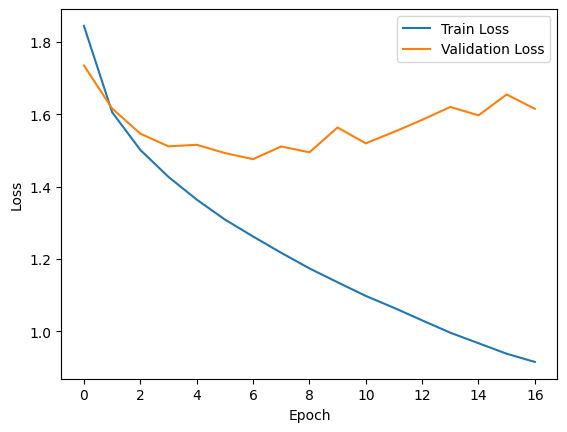

In [8]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader, random_split
from copy import deepcopy

# =========================
# 1. Data Preparation
# =========================
transform = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

train_and_valid_data = torchvision.datasets.CIFAR10(
    root="datasets", train=True, download=True, transform=transform)

test_data = torchvision.datasets.CIFAR10(
    root="datasets", train=False, download=True, transform=transform)

torch.manual_seed(42)
train_data, valid_data = random_split(train_and_valid_data, [45_000, 5_000])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_data, batch_size=32, num_workers=2)
test_loader = DataLoader(test_data, batch_size=32, num_workers=2)

# =========================
# 2. Model Definition
# =========================
n_inputs = 32 * 32 * 3
n_hidden_layers = 20
n_neurons = 100
n_outputs = 10

layers = [nn.Flatten()]

for i in range(n_hidden_layers):
    in_features = n_inputs if i == 0 else n_neurons
    layers.append(nn.Linear(in_features, n_neurons))
    layers.append(nn.SiLU())  # Swish activation

layers.append(nn.Linear(n_neurons, n_outputs))

model = nn.Sequential(*layers)

# =========================
# 3. He Initialization
# =========================
def initialize_weights(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
        nn.init.zeros_(module.bias)

model.apply(initialize_weights)

# =========================
# 4. Training Setup
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

lr = 5e-4 
optimizer = torch.optim.NAdam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

# Early stopping
n_epochs = 100
patience = 10
best_valid_loss = float("inf")
best_model_state = None
patience_counter = 0

# =========================
# 5. Training Loop
# =========================
train_losses = []
val_losses = []

for epoch in range(n_epochs):

    # ----- Training -----
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ----- Validation -----
    model.eval()
    valid_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_val, y_val in valid_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)

            y_val_pred = model(X_val)
            loss = criterion(y_val_pred, y_val)
            valid_loss += loss.item()

            _, predicted = torch.max(y_val_pred, 1)
            correct += (predicted == y_val).sum().item()
            total += y_val.size(0)

    valid_loss /= len(valid_loader)
    val_acc = correct / total

    train_losses.append(train_loss)
    val_losses.append(valid_loss)

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {valid_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}")

    # ----- Early Stopping -----
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_model_state = deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("⛔ Early stopping triggered.")
            break

# Restore best model
model.load_state_dict(best_model_state)

# =========================
# 6. Test Evaluation
# =========================
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X_test, y_test in test_loader:
        X_test, y_test = X_test.to(device), y_test.to(device)

        outputs = model(X_test)
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == y_test).sum().item()
        total += y_test.size(0)

test_acc = correct / total
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### d. Now try adding batch-norm and compare the learning curves: is it converging faster than before? Does it produce a better model? How does it affect training speed?

Epoch 01 | Train Loss: 1.1938 | Val Loss: 1.5174 | Val Acc: 0.4758
⛔ Early stopping triggered.

✅ Test Accuracy: 0.0911


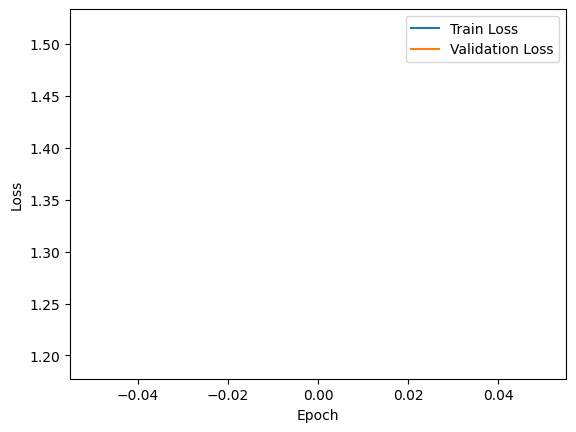

In [9]:
# =========================
# 2. Model Definition (WITH BatchNorm)
# =========================
layers_bn = [nn.Flatten()]

for i in range(n_hidden_layers):
    in_features = n_inputs if i == 0 else n_neurons
    
    layers_bn.append(nn.Linear(in_features, n_neurons))
    layers_bn.append(nn.BatchNorm1d(n_neurons))  # ✅ Added
    layers_bn.append(nn.SiLU())

layers_bn.append(nn.Linear(n_neurons, n_outputs))

model_bn = nn.Sequential(*layers_bn)

# Apply He initialization
model_bn.apply(initialize_weights)

model_bn.to(device)

# Optimizer
optimizer_bn = torch.optim.NAdam(model_bn.parameters(), lr=lr)

# =========================
# 5. Training Loop
# =========================
train_losses = []
val_losses = []

for epoch in range(n_epochs):

    # ----- Training -----
    model_bn.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ----- Validation -----
    model_bn.eval()
    valid_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_val, y_val in valid_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)

            y_val_pred = model(X_val)
            loss = criterion(y_val_pred, y_val)
            valid_loss += loss.item()

            _, predicted = torch.max(y_val_pred, 1)
            correct += (predicted == y_val).sum().item()
            total += y_val.size(0)

    valid_loss /= len(valid_loader)
    val_acc = correct / total

    train_losses.append(train_loss)
    val_losses.append(valid_loss)

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {valid_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}")

    # ----- Early Stopping -----
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_model_state = deepcopy(model_bn.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("⛔ Early stopping triggered.")
            break

# Restore best model
model.load_state_dict(best_model_state)

# =========================
# 6. Test Evaluation
# =========================
model_bn.eval()
correct = 0
total = 0

with torch.no_grad():
    for X_test, y_test in test_loader:
        X_test, y_test = X_test.to(device), y_test.to(device)

        outputs = model_bn(X_test)
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == y_test).sum().item()
        total += y_test.size(0)

test_acc = correct / total
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### e. Try replacing batch-norm with SELU, and make the necessary adjustments to ensure the network self-normalizes (i.e., standardize the input features, use LeCun normal initialization, make sure the DNN contains only a sequence of dense layers, etc.).

In [10]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader, random_split
from copy import deepcopy

# =========================
# 1. Data Preparation (STANDARDIZED INPUT)
# =========================

# CIFAR-10 mean and std (precomputed)
cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std = (0.2470, 0.2435, 0.2616)

transform = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=cifar10_mean, std=cifar10_std)  # ✅ required for SELU
])

train_and_valid_data = torchvision.datasets.CIFAR10(
    root="datasets", train=True, download=True, transform=transform)

test_data = torchvision.datasets.CIFAR10(
    root="datasets", train=False, download=True, transform=transform)

torch.manual_seed(42)
train_data, valid_data = random_split(train_and_valid_data, [45_000, 5_000])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_data, batch_size=32, num_workers=2)
test_loader = DataLoader(test_data, batch_size=32, num_workers=2)

# =========================
# 2. Model Definition (SELU ONLY)
# =========================
n_inputs = 32 * 32 * 3
n_hidden_layers = 20
n_neurons = 100
n_outputs = 10

layers = [nn.Flatten()]

for i in range(n_hidden_layers):
    in_features = n_inputs if i == 0 else n_neurons
    layers.append(nn.Linear(in_features, n_neurons))
    layers.append(nn.SELU())  # ✅ SELU activation

    # Optional: AlphaDropout (only if needed)
    # layers.append(nn.AlphaDropout(p=0.1))

layers.append(nn.Linear(n_neurons, n_outputs))

model = nn.Sequential(*layers)

# =========================
# 3. LeCun Normal Initialization
# =========================
def lecun_init(module):
    if isinstance(module, nn.Linear):
        fan_in = module.weight.size(1)
        std = (1.0 / fan_in) ** 0.5
        nn.init.normal_(module.weight, mean=0.0, std=std)
        nn.init.zeros_(module.bias)

model.apply(lecun_init)

# =========================
# 4. Training Setup
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

lr = 5e-4
optimizer = torch.optim.NAdam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

# Early stopping
n_epochs = 100
patience = 10
best_valid_loss = float("inf")
best_model_state = None
patience_counter = 0

train_losses = []
val_losses = []

# =========================
# 5. Training Loop
# =========================
for epoch in range(n_epochs):

    # ----- Training -----
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ----- Validation -----
    model.eval()
    valid_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_val, y_val in valid_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)

            y_val_pred = model(X_val)
            loss = criterion(y_val_pred, y_val)
            valid_loss += loss.item()

            _, predicted = torch.max(y_val_pred, 1)
            correct += (predicted == y_val).sum().item()
            total += y_val.size(0)

    valid_loss /= len(valid_loader)
    val_acc = correct / total

    train_losses.append(train_loss)
    val_losses.append(valid_loss)

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {valid_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}")

    # Early stopping
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_model_state = deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("⛔ Early stopping triggered.")
            break

# Restore best model
model.load_state_dict(best_model_state)

# =========================
# 6. Test Evaluation
# =========================
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X_test, y_test in test_loader:
        X_test, y_test = X_test.to(device), y_test.to(device)

        outputs = model(X_test)
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == y_test).sum().item()
        total += y_test.size(0)

test_acc = correct / total
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

Epoch 01 | Train Loss: 1.8672 | Val Loss: 1.8073 | Val Acc: 0.3532
Epoch 02 | Train Loss: 1.6654 | Val Loss: 1.6487 | Val Acc: 0.4090
Epoch 03 | Train Loss: 1.5658 | Val Loss: 1.5799 | Val Acc: 0.4508
Epoch 04 | Train Loss: 1.4965 | Val Loss: 1.5217 | Val Acc: 0.4714
Epoch 05 | Train Loss: 1.4366 | Val Loss: 1.5849 | Val Acc: 0.4554
Epoch 06 | Train Loss: 1.3870 | Val Loss: 1.4785 | Val Acc: 0.4860
Epoch 07 | Train Loss: 1.3414 | Val Loss: 1.5203 | Val Acc: 0.4722
Epoch 08 | Train Loss: 1.2996 | Val Loss: 1.4874 | Val Acc: 0.4944
Epoch 09 | Train Loss: 1.2594 | Val Loss: 1.5216 | Val Acc: 0.4804
Epoch 10 | Train Loss: 1.2288 | Val Loss: 1.5118 | Val Acc: 0.4842
Epoch 11 | Train Loss: 1.1987 | Val Loss: 1.4922 | Val Acc: 0.5054
Epoch 12 | Train Loss: 1.1693 | Val Loss: 1.4930 | Val Acc: 0.5018
Epoch 13 | Train Loss: 1.1378 | Val Loss: 1.5116 | Val Acc: 0.4956
Epoch 14 | Train Loss: 1.1065 | Val Loss: 1.5103 | Val Acc: 0.4998
Epoch 15 | Train Loss: 1.0809 | Val Loss: 1.4824 | Val Acc: 0.

: 

### f. Try regularizing the model with alpha dropout. Then, without retraining your model, see if you can achieve better accuracy using MC dropout.

In [7]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader, random_split
from copy import deepcopy

# =========================
# 1. Data Preparation (STANDARDIZED INPUT)
# =========================

# CIFAR-10 mean and std (precomputed)
cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std = (0.2470, 0.2435, 0.2616)

transform = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=cifar10_mean, std=cifar10_std)  # ✅ required for SELU
])

train_and_valid_data = torchvision.datasets.CIFAR10(
    root="datasets", train=True, download=True, transform=transform)

test_data = torchvision.datasets.CIFAR10(
    root="datasets", train=False, download=True, transform=transform)

torch.manual_seed(42)
train_data, valid_data = random_split(train_and_valid_data, [45_000, 5_000])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_data, batch_size=32, num_workers=2)
test_loader = DataLoader(test_data, batch_size=32, num_workers=2)

# =========================
# 2. Model Definition (SELU + Alpha Dropout)
# =========================
n_inputs = 32 * 32 * 3
n_hidden_layers = 20
n_neurons = 100
n_outputs = 10
dropout_rate = 0.1

layers = [nn.Flatten()]

for i in range(n_hidden_layers):
    in_features = n_inputs if i == 0 else n_neurons
    
    layers.append(nn.AlphaDropout(p=dropout_rate))  # ✅ before Linear
    layers.append(nn.Linear(in_features, n_neurons))
    layers.append(nn.SELU())

layers.append(nn.Linear(n_neurons, n_outputs))

model = nn.Sequential(*layers)

# =========================
# 3. LeCun Normal Initialization
# =========================
def lecun_init(module):
    if isinstance(module, nn.Linear):
        fan_in = module.weight.size(1)
        std = (1.0 / fan_in) ** 0.5
        nn.init.normal_(module.weight, mean=0.0, std=std)
        nn.init.zeros_(module.bias)

model.apply(lecun_init)

# =========================
# 4. Training Setup
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

lr = 5e-4
optimizer = torch.optim.NAdam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

# Early stopping
n_epochs = 100
patience = 10
best_valid_loss = float("inf")
best_model_state = None
patience_counter = 0

train_losses = []
val_losses = []

# =========================
# 5. Training Loop
# =========================
for epoch in range(n_epochs):

    # ----- Training -----
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ----- Validation -----
    model.eval()
    valid_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_val, y_val in valid_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)

            y_val_pred = model(X_val)
            loss = criterion(y_val_pred, y_val)
            valid_loss += loss.item()

            _, predicted = torch.max(y_val_pred, 1)
            correct += (predicted == y_val).sum().item()
            total += y_val.size(0)

    valid_loss /= len(valid_loader)
    val_acc = correct / total

    train_losses.append(train_loss)
    val_losses.append(valid_loss)

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {valid_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}")

    # Early stopping
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_model_state = deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("⛔ Early stopping triggered.")
            break

# Restore best model
model.load_state_dict(best_model_state)

# Restore best model
model.load_state_dict(best_model_state)

# =========================
# MC Dropout Function (ADD HERE)
# =========================
import torch.nn.functional as F

def mc_dropout_predict(model, X_batch, n_samples=50):
    X_batch = X_batch.to(device)

    X_repeated = X_batch.repeat_interleave(n_samples, dim=0)

    with torch.no_grad():
        logits = model(X_repeated)
        logits = logits.view(X_batch.size(0), n_samples, -1)
        probs = F.softmax(logits, dim=-1).mean(dim=1)

    return probs

# =========================
# 6. Test Evaluation with MC Dropout
# =========================
model.eval()

for module in model.modules():
    if isinstance(module, nn.AlphaDropout):
        module.train()

correct = 0
total = 0

for X_test, y_test in test_loader:
    y_probs = mc_dropout_predict(model, X_test, n_samples=50)
    y_pred = y_probs.argmax(dim=1)

    correct += (y_pred.cpu() == y_test).sum().item()
    total += y_test.size(0)

mc_test_acc = correct / total
print(f"\n✅ MC Dropout Test Accuracy: {mc_test_acc:.4f}")

Epoch 01 | Train Loss: 2.1253 | Val Loss: 2.5742 | Val Acc: 0.1940
Epoch 02 | Train Loss: 1.9916 | Val Loss: 3.4594 | Val Acc: 0.2738
Epoch 03 | Train Loss: 1.9459 | Val Loss: 5.3102 | Val Acc: 0.2924
Epoch 04 | Train Loss: 1.8849 | Val Loss: 5.3086 | Val Acc: 0.3048
Epoch 05 | Train Loss: 1.8417 | Val Loss: 5.1579 | Val Acc: 0.3184
Epoch 06 | Train Loss: 1.8055 | Val Loss: 4.6115 | Val Acc: 0.3324
Epoch 07 | Train Loss: 1.7713 | Val Loss: 4.0343 | Val Acc: 0.3440
Epoch 08 | Train Loss: 1.7389 | Val Loss: 5.7434 | Val Acc: 0.3454
Epoch 09 | Train Loss: 1.7128 | Val Loss: 4.8688 | Val Acc: 0.3662
Epoch 10 | Train Loss: 1.7005 | Val Loss: 5.3612 | Val Acc: 0.3760
Epoch 11 | Train Loss: 1.6712 | Val Loss: 4.8890 | Val Acc: 0.3874
⛔ Early stopping triggered.

✅ MC Dropout Test Accuracy: 0.2261


### g. Retrain your model using 1cycle scheduling and see if it improves training speed and model accuracy.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader, random_split
from copy import deepcopy

# =========================
# 1. Data Preparation
# =========================
# CIFAR10 mean & std for standardization (required for SELU self-normalization)
cifar10_mean = [0.4914, 0.4822, 0.4465]
cifar10_std = [0.2470, 0.2435, 0.2616]

transform = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=cifar10_mean, std=cifar10_std)
])

train_and_valid_data = torchvision.datasets.CIFAR10(
    root="datasets", train=True, download=True, transform=transform
)
test_data = torchvision.datasets.CIFAR10(
    root="datasets", train=False, download=True, transform=transform
)

torch.manual_seed(42)
train_data, valid_data = random_split(train_and_valid_data, [45_000, 5_000])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_data, batch_size=32, num_workers=2)
test_loader = DataLoader(test_data, batch_size=32, num_workers=2)

# =========================
# 2. Model Definition (SELU + Alpha Dropout)
# =========================
n_inputs = 32 * 32 * 3
n_hidden_layers = 20
n_neurons = 100
n_outputs = 10
dropout_rate = 0.1

layers = [nn.Flatten()]

for i in range(n_hidden_layers):
    in_features = n_inputs if i == 0 else n_neurons
    layers.append(nn.AlphaDropout(p=dropout_rate))  # Alpha Dropout for SELU
    layers.append(nn.Linear(in_features, n_neurons))
    layers.append(nn.SELU())

layers.append(nn.Linear(n_neurons, n_outputs))
model = nn.Sequential(*layers)

# =========================
# 3. LeCun Normal Initialization
# =========================
def lecun_normal_init(module):
    if isinstance(module, nn.Linear):
        fan_in = module.weight.size(1)
        std = (1.0 / fan_in) ** 0.5
        nn.init.normal_(module.weight, mean=0.0, std=std)
        nn.init.zeros_(module.bias)

model.apply(lecun_normal_init)

# =========================
# 4. Training Setup (NAdam + 1cycle)
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Learning rates for 1cycle
max_lr = 5e-3
epochs = 50
steps_per_epoch = len(train_loader)
optimizer = torch.optim.NAdam(model.parameters(), lr=max_lr / 10)
criterion = nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=max_lr, epochs=epochs, steps_per_epoch=steps_per_epoch
)

# Early stopping parameters (optional)
patience = 10
best_valid_loss = float("inf")
best_model_state = None
patience_counter = 0

# Store losses for plotting
train_losses = []
val_losses = []

# =========================
# 5. Training Loop
# =========================
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        scheduler.step()  # Step scheduler per batch

        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # ----- Validation -----
    model.eval()
    valid_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_val, y_val in valid_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            y_val_pred = model(X_val)
            loss = criterion(y_val_pred, y_val)
            valid_loss += loss.item()

            _, predicted = torch.max(y_val_pred, 1)
            correct += (predicted == y_val).sum().item()
            total += y_val.size(0)

    valid_loss /= len(valid_loader)
    val_losses.append(valid_loss)
    val_acc = correct / total

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {valid_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}")

    # Early stopping
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_model_state = deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("⛔ Early stopping triggered.")
            break

# Restore best model
model.load_state_dict(best_model_state)

# =========================
# 6. Test Evaluation
# =========================
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X_test, y_test in test_loader:
        X_test, y_test = X_test.to(device), y_test.to(device)
        outputs = model(X_test)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_test).sum().item()
        total += y_test.size(0)

test_acc = correct / total
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

# =========================
# 7. MC Dropout for inference
# =========================
# Force AlphaDropout layers to train mode
for module in model.modules():
    if isinstance(module, nn.AlphaDropout):
        module.train()

def mc_dropout_predict(model, X_batch, n_samples=100):
    X_repeated = X_batch.repeat_interleave(n_samples, dim=0)
    with torch.no_grad():
        y_logits = model(X_repeated)
        y_logits = y_logits.view(X_batch.size(0), n_samples, -1)
        y_probs = F.softmax(y_logits, dim=-1).mean(dim=1)
    return y_probs

# Example: MC dropout on test batch
X_test_batch, y_test_batch = next(iter(test_loader))
X_test_batch, y_test_batch = X_test_batch.to(device), y_test_batch.to(device)
y_probs = mc_dropout_predict(model, X_test_batch)
y_pred = y_probs.argmax(dim=1)
mc_acc = (y_pred == y_test_batch).float().mean().item()
print(f"MC Dropout Accuracy (sample batch): {mc_acc:.4f}")